# Exploratory Data Analysis & Data Cleaning

Before fine-tuning, we need to understand what our data actually looks like.  
This notebook performs:
1. **Exploratory analysis** — distributions, patterns, anomalies
2. **Quality checks** — identify specific issues
3. **Targeted cleaning** — fix only what the analysis reveals
4. **Validation** — confirm the fixes worked

In [1]:
import json
import re
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 11

In [2]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

def save_jsonl(records, path):
    with open(path, 'w') as f:
        for r in records:
            f.write(json.dumps(r) + '\n')

In [3]:
# Load raw data
train = load_jsonl('../data/train.jsonl')
eval_data = load_jsonl('../data/eval.jsonl')
all_data = train + eval_data

# Parse all outputs into dicts for analysis
train_outputs = [json.loads(ex['output']) for ex in train]
eval_outputs = [json.loads(ex['output']) for ex in eval_data]
all_outputs = train_outputs + eval_outputs

print(f'Train: {len(train)} samples')
print(f'Eval:  {len(eval_data)} samples')
print(f'Total: {len(all_data)} samples')

Train: 2524 samples
Eval:  500 samples
Total: 3024 samples


---
## 1. Dataset Overview
Let's first understand the basic structure — what fields are present, how many are filled, and what the data looks like.

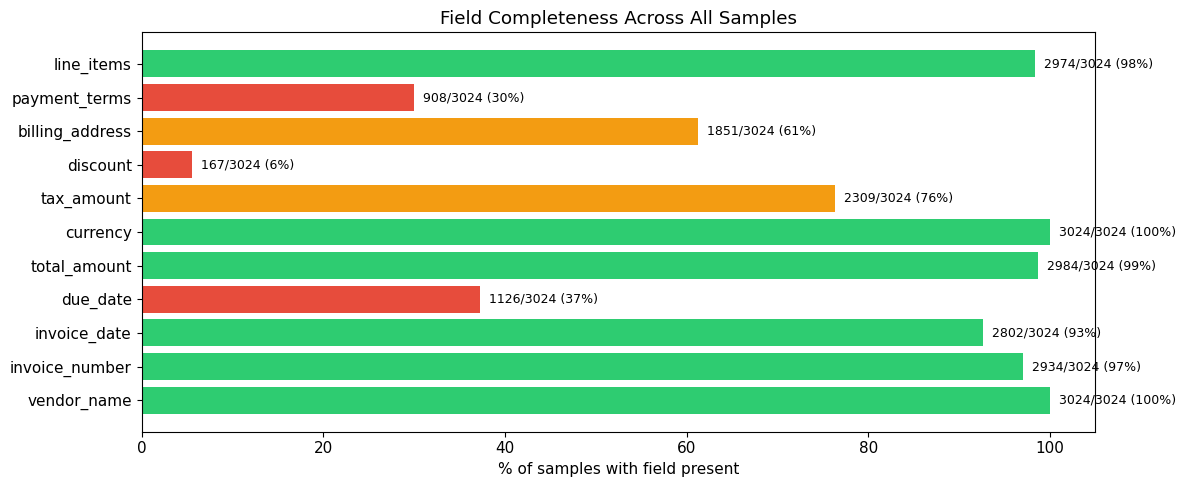

In [5]:
# Field completeness analysis
fields = ['vendor_name', 'invoice_number', 'invoice_date', 'due_date',
          'total_amount', 'currency', 'tax_amount', 'discount',
          'billing_address', 'payment_terms', 'line_items']

field_stats = {}
for field in fields:
    filled = 0
    for out in all_outputs:
        val = out.get(field)
        if val is not None and val != '' and val != [] and val != 0:
            filled += 1
    field_stats[field] = filled

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v/len(all_data) > 0.9 else '#f39c12' if v/len(all_data) > 0.5 else '#e74c3c' 
          for v in field_stats.values()]
bars = ax.barh(list(field_stats.keys()), 
               [v/len(all_data)*100 for v in field_stats.values()],
               color=colors)
ax.set_xlabel('% of samples with field present')
ax.set_title('Field Completeness Across All Samples')
ax.set_xlim(0, 105)
for bar, val in zip(bars, field_stats.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}/{len(all_data)} ({val/len(all_data)*100:.0f}%)',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# Look at a few samples to understand the structure
print('=== Sample 1: Input (invoice text) ===\n')
print(train[0]['input'][:500])
print('\n=== Sample 1: Output (extracted JSON) ===\n')
print(train[0]['output'][:500])
print('\n' + '='*60)
print('\n=== Sample 2: Input ===\n')
print(train[100]['input'][:500])

=== Sample 1: Input (invoice text) ===

Thecooperative food Cureral England Co-ocoraivo Central Ergland Co-operative VAT508037563 OPER10R:999004 PR EO-OP WHOLEMERL LOR 0.75 PR CO-OP SOFT CHSE 1.05 PR 4.25 PR CP RASPEERRIES PUNN 2.00 PR GOAHEAD CRISPY FRUI 1.00 PR CP BBY.JERSEY ROYALS 1.00 PR NAP TOM PASSATA 0.59 PR CO-OP BAGUETTES 1.39 PR NAP TOM PASSATA 0.59 AMOUNT DUE 12.62 VF Credit Card 12.62 ACCOUNT NUMBER **** **9378 ATH003773 CHANGE 0.00 Please follou us on Titter @ycoopfood 12/05/201511:360626024 0032999004 Visit us at ww.cent

=== Sample 1: Output (extracted JSON) ===

{
  "vendor_name": "Thecooperative food Cureral England Co-ocoraivo Central Ergland Co-operative",
  "invoice_number": "999004",
  "invoice_date": "2015-12-05",
  "due_date": "",
  "total_amount": 12.62,
  "currency": "USD",
  "tax_amount": null,
  "discount": null,
  "billing_address": null,
  "payment_terms": null,
  "line_items": [
    {
      "description": "WHOLEMERL",
      "quantity": 0.75,
      "unit_pr

---
## 2. Text Length Distribution
Understanding token lengths helps us choose `max_seq_length` for training — too short truncates data, too long wastes GPU memory.

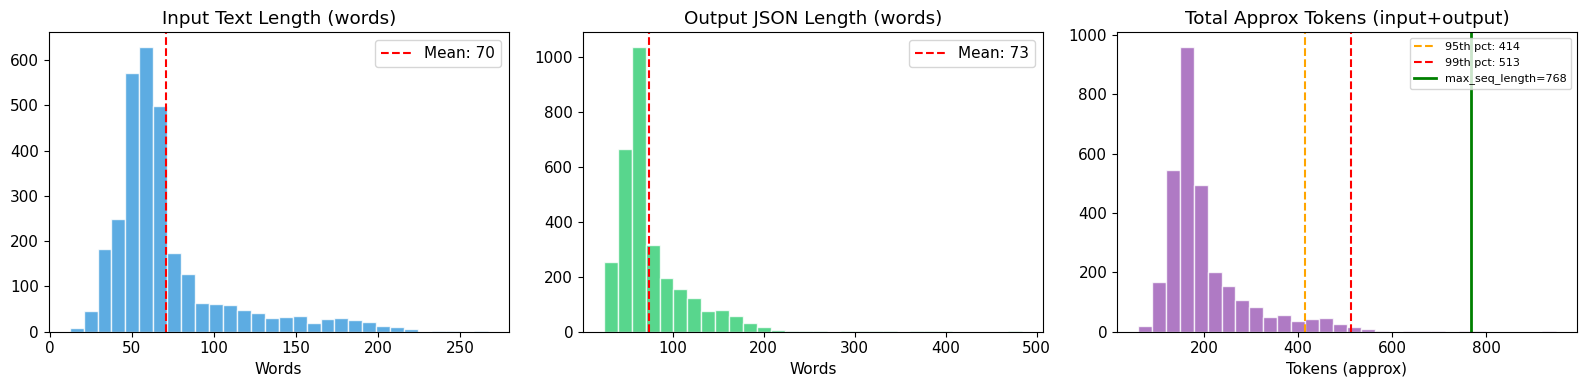


Samples exceeding 768 tokens: 2/3024 (0.1%)
Recommendation: max_seq_length=768 is safe — covers 99%+ of data


In [7]:
# Calculate approximate token lengths for full prompt
# (instruction + input + output, tokenizer uses ~1.3 tokens per word)
input_lengths = [len(ex['input'].split()) for ex in all_data]
output_lengths = [len(ex['output'].split()) for ex in all_data]
total_word_lengths = [len(ex['input'].split()) + len(ex['output'].split()) + 10 for ex in all_data]  # +10 for instruction
approx_token_lengths = [int(w * 1.3) for w in total_word_lengths]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(input_lengths, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=sum(input_lengths)/len(input_lengths), color='red', linestyle='--', label=f'Mean: {sum(input_lengths)//len(input_lengths)}')
axes[0].set_title('Input Text Length (words)')
axes[0].set_xlabel('Words')
axes[0].legend()

axes[1].hist(output_lengths, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].axvline(x=sum(output_lengths)/len(output_lengths), color='red', linestyle='--', label=f'Mean: {sum(output_lengths)//len(output_lengths)}')
axes[1].set_title('Output JSON Length (words)')
axes[1].set_xlabel('Words')
axes[1].legend()

axes[2].hist(approx_token_lengths, bins=30, color='#9b59b6', edgecolor='white', alpha=0.8)
p95 = sorted(approx_token_lengths)[int(len(approx_token_lengths)*0.95)]
p99 = sorted(approx_token_lengths)[int(len(approx_token_lengths)*0.99)]
axes[2].axvline(x=p95, color='orange', linestyle='--', label=f'95th pct: {p95}')
axes[2].axvline(x=p99, color='red', linestyle='--', label=f'99th pct: {p99}')
axes[2].axvline(x=768, color='green', linestyle='-', linewidth=2, label='max_seq_length=768')
axes[2].set_title('Total Approx Tokens (input+output)')
axes[2].set_xlabel('Tokens (approx)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

over_768 = sum(1 for t in approx_token_lengths if t > 768)
print(f'\nSamples exceeding 768 tokens: {over_768}/{len(approx_token_lengths)} ({over_768/len(approx_token_lengths)*100:.1f}%)')
print(f'Recommendation: max_seq_length=768 is safe — covers 99%+ of data')

---
## 3. Currency Distribution
Check how diverse our currency representation is and whether there's heavy class imbalance.

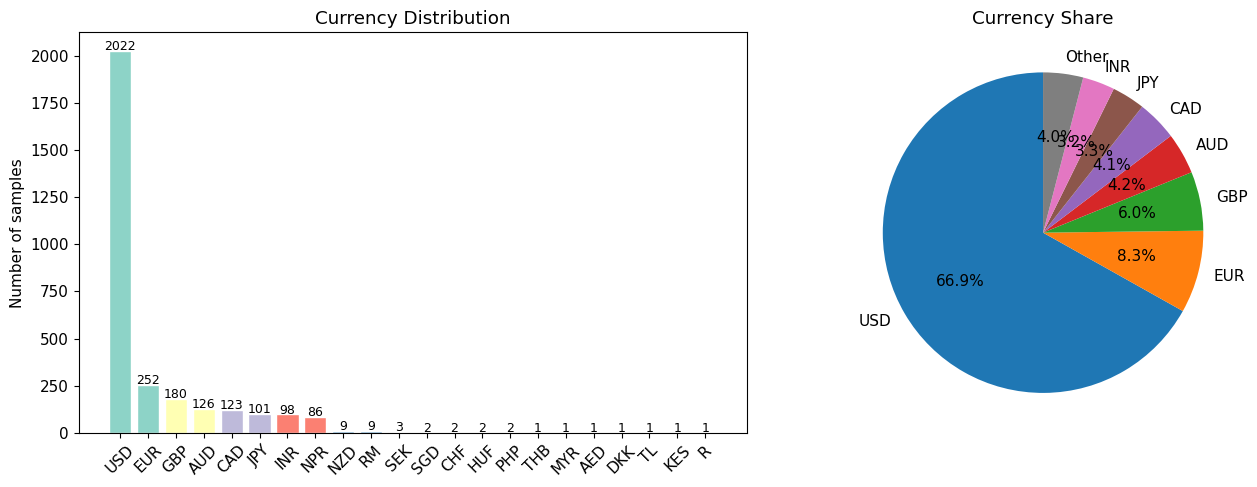

In [9]:
currencies = Counter(out.get('currency', 'unknown') for out in all_outputs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sorted_currencies = currencies.most_common()
labels, values = zip(*sorted_currencies)
colors_bar = plt.cm.Set3([i/len(labels) for i in range(len(labels))])
ax1.bar(labels, values, color=colors_bar, edgecolor='white')
ax1.set_title('Currency Distribution')
ax1.set_ylabel('Number of samples')
ax1.tick_params(axis='x', rotation=45)
for i, (l, v) in enumerate(zip(labels, values)):
    ax1.text(i, v + 5, str(v), ha='center', fontsize=9)

# Pie chart
top_6 = currencies.most_common(7)
other_count = sum(v for k, v in currencies.items() if k not in dict(top_6))
pie_labels = [k for k, v in top_6]
pie_values = [v for k, v in top_6]
if other_count > 0:
    pie_labels.append('Other')
    pie_values.append(other_count)
ax2.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Currency Share')

plt.tight_layout()
plt.show()

---
## 4. Date Format Analysis
Consistent date formats in the output are critical — if the model sees multiple formats during training, it won't know which to produce during inference.

In [10]:
def classify_date_format(date_str):
    if not date_str or not isinstance(date_str, str):
        return 'missing'
    date_str = date_str.strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str): return 'YYYY-MM-DD'
    if re.match(r'^\d{2}/\d{2}/\d{4}$', date_str): return 'MM/DD/YYYY'
    if re.match(r'^\d{2}-\w{3}-\d{4}$', date_str): return 'DD-Mon-YYYY'
    if re.match(r'^\d{4}/\d{2}/\d{2}$', date_str): return 'YYYY/MM/DD'
    if re.match(r'^\d{2}/\d{2}/\d{2}$', date_str): return 'MM/DD/YY'
    if re.match(r'^\d{2}-\d{2}-\d{4}$', date_str): return 'DD-MM-YYYY'
    return f'other'


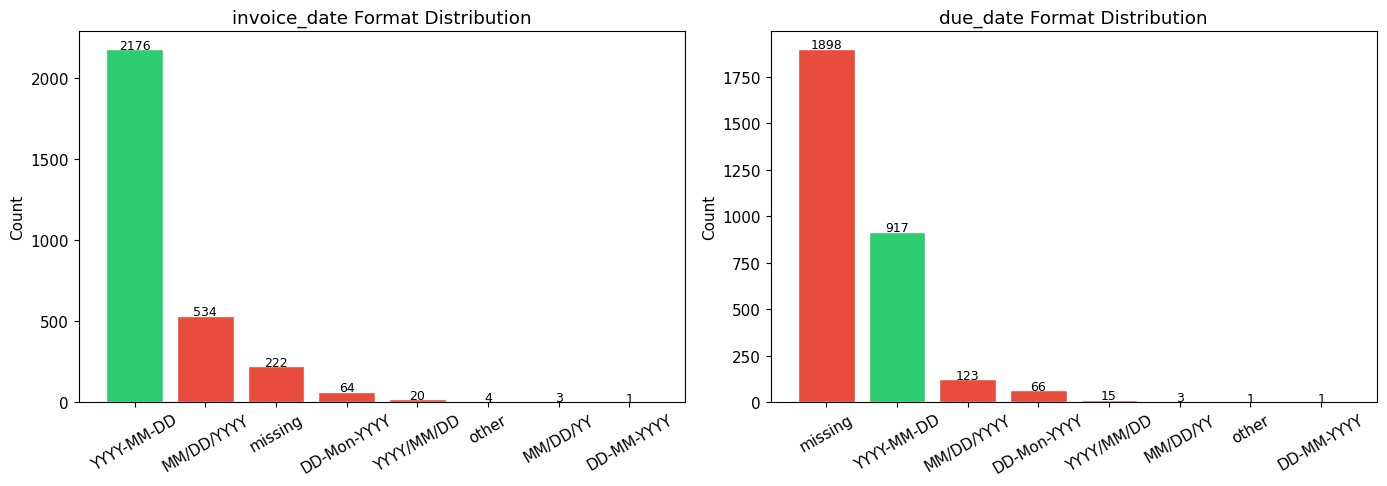


Finding: 848 samples (28.0%) have non-standard date formats in invoice_date
Action needed: Standardize all dates to YYYY-MM-DD for consistent model output


In [11]:
# Analyze invoice_date formats
invoice_date_fmts = Counter(classify_date_format(out.get('invoice_date', '')) for out in all_outputs)
due_date_fmts = Counter(classify_date_format(out.get('due_date', '')) for out in all_outputs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels1, vals1 = zip(*invoice_date_fmts.most_common())
colors1 = ['#2ecc71' if l == 'YYYY-MM-DD' else '#e74c3c' for l in labels1]
ax1.bar(labels1, vals1, color=colors1, edgecolor='white')
ax1.set_title('invoice_date Format Distribution')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(vals1):
    ax1.text(i, v + 3, str(v), ha='center', fontsize=9)

labels2, vals2 = zip(*due_date_fmts.most_common())
colors2 = ['#2ecc71' if l == 'YYYY-MM-DD' else '#e74c3c' for l in labels2]
ax2.bar(labels2, vals2, color=colors2, edgecolor='white')
ax2.set_title('due_date Format Distribution')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=30)
for i, v in enumerate(vals2):
    ax2.text(i, v + 3, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

non_standard = sum(v for k, v in invoice_date_fmts.items() if k != 'YYYY-MM-DD')
print(f'\nFinding: {non_standard} samples ({non_standard/len(all_data)*100:.1f}%) have non-standard date formats in invoice_date')
print('Action needed: Standardize all dates to YYYY-MM-DD for consistent model output')

---
## 5. Total Amount Distribution & Line Item Math Validation
For structured extraction, mathematical consistency matters. If line_items don't add up to total_amount, the model learns wrong arithmetic.

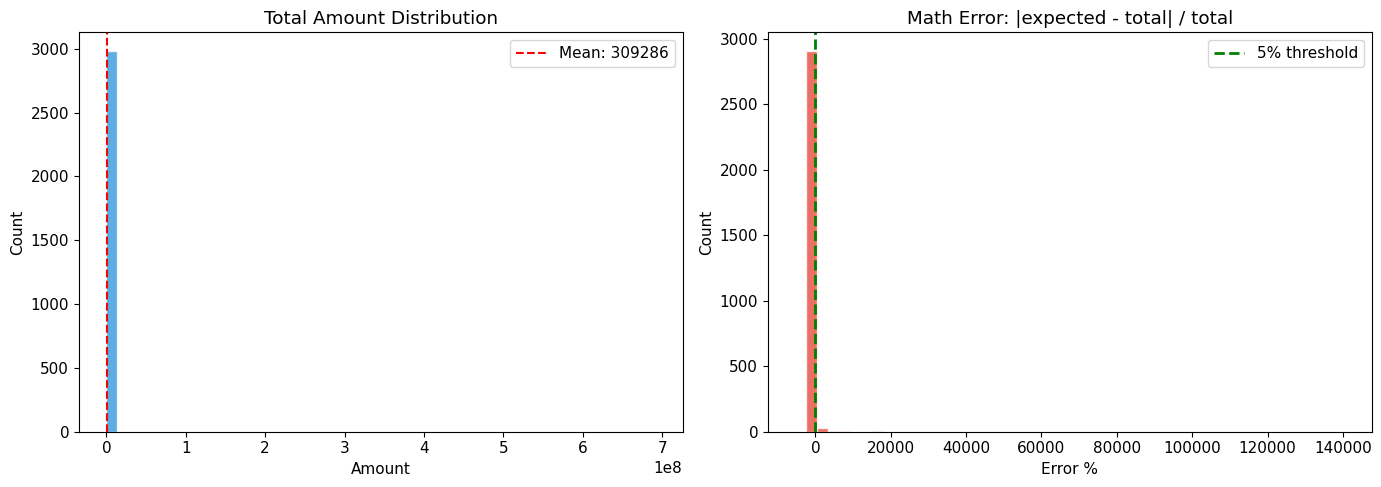


Finding: 1283 samples (42.4%) have line items that don't add up to total (>5% error)
Action needed: Remove these samples — they teach the model incorrect arithmetic


In [12]:
# Total amount distribution
totals = [out.get('total_amount', 0) for out in all_outputs if out.get('total_amount', 0) > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(totals, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax1.set_title('Total Amount Distribution')
ax1.set_xlabel('Amount')
ax1.set_ylabel('Count')
ax1.axvline(x=sum(totals)/len(totals), color='red', linestyle='--', label=f'Mean: {sum(totals)/len(totals):.0f}')
ax1.legend()

# Math consistency check
errors = []
for out in all_outputs:
    items = out.get('line_items', [])
    total = out.get('total_amount', 0)
    if not items or total == 0:
        continue
    items_total = sum(item.get('line_total', 0) for item in items)
    tax = out.get('tax_amount') or 0
    discount = out.get('discount') or 0
    expected = items_total + tax - discount
    error_pct = abs(expected - total) / total * 100
    errors.append(error_pct)

ax2.hist(errors, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
ax2.axvline(x=5, color='green', linestyle='--', linewidth=2, label='5% threshold')
ax2.set_title('Math Error: |expected - total| / total')
ax2.set_xlabel('Error %')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()

bad_math = sum(1 for e in errors if e > 5)
print(f'\nFinding: {bad_math} samples ({bad_math/len(all_data)*100:.1f}%) have line items that don\'t add up to total (>5% error)')
print('Action needed: Remove these samples — they teach the model incorrect arithmetic')

---
## 6. Line Items Analysis
How many line items per invoice? Are there any with zero items? Are item descriptions diverse enough?

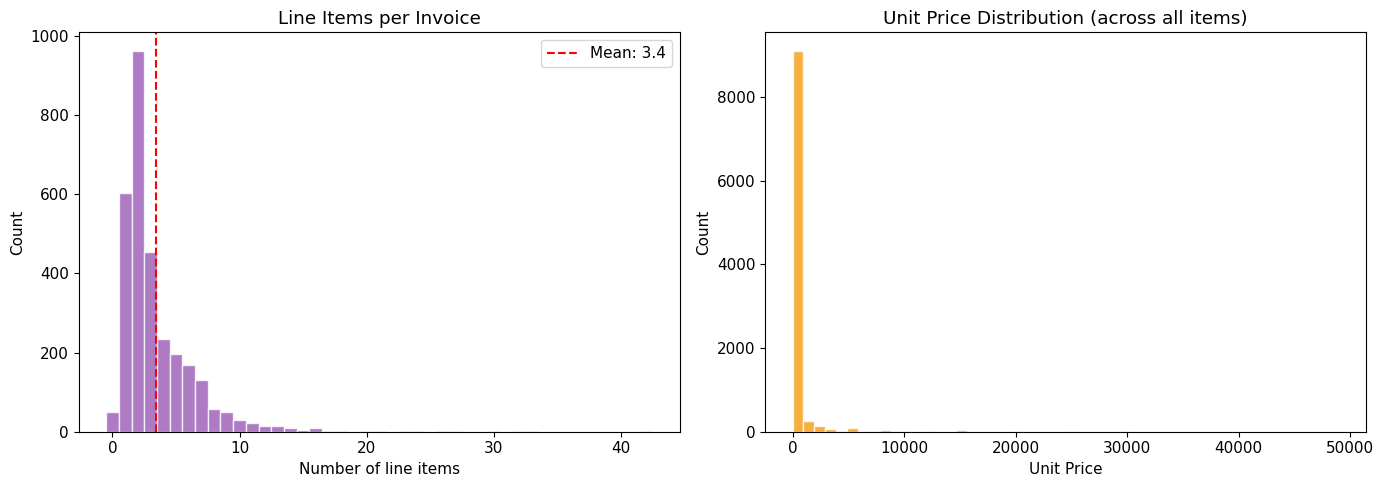

Invoices with 0 line items: 50
Avg items per invoice: 3.4
Max items in one invoice: 42


In [13]:
item_counts = [len(out.get('line_items', [])) for out in all_outputs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(item_counts, bins=range(0, max(item_counts)+2), color='#9b59b6', edgecolor='white', alpha=0.8, align='left')
ax1.set_title('Line Items per Invoice')
ax1.set_xlabel('Number of line items')
ax1.set_ylabel('Count')
ax1.axvline(x=sum(item_counts)/len(item_counts), color='red', linestyle='--', label=f'Mean: {sum(item_counts)/len(item_counts):.1f}')
ax1.legend()

# Unit price distribution
prices = []
for out in all_outputs:
    for item in out.get('line_items', []):
        p = item.get('unit_price', 0)
        if isinstance(p, (int, float)) and 0 < p < 50000:
            prices.append(p)

ax2.hist(prices, bins=50, color='#f39c12', edgecolor='white', alpha=0.8)
ax2.set_title('Unit Price Distribution (across all items)')
ax2.set_xlabel('Unit Price')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

zero_items = sum(1 for c in item_counts if c == 0)
print(f'Invoices with 0 line items: {zero_items}')
print(f'Avg items per invoice: {sum(item_counts)/len(item_counts):.1f}')
print(f'Max items in one invoice: {max(item_counts)}')

---
## 7. Duplicate & Near-Duplicate Detection
Duplicates in the training set waste capacity and can cause overfitting.

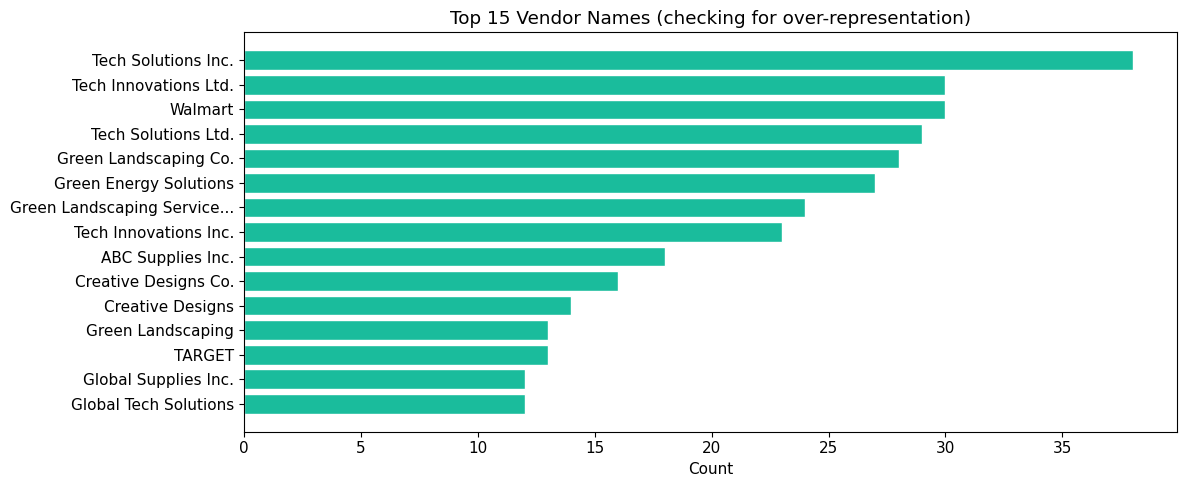

Exact duplicate inputs: 0
Near-duplicate inputs (same first 50 chars): 60
Unique vendor names: 2204


In [14]:
# Exact duplicates
input_texts = [ex['input'] for ex in all_data]
unique_inputs = set(input_texts)
exact_dups = len(input_texts) - len(unique_inputs)

# Near-duplicates: check first 50 chars
prefixes = Counter(text[:50] for text in input_texts)
near_dups = sum(v - 1 for v in prefixes.values() if v > 1)

# Vendor name diversity
vendors = Counter(out.get('vendor_name', '') for out in all_outputs)
top_vendors = vendors.most_common(15)

fig, ax = plt.subplots(figsize=(12, 5))
v_labels, v_counts = zip(*top_vendors)
v_labels_short = [l[:25] + '...' if len(l) > 25 else l for l in v_labels]
ax.barh(v_labels_short, v_counts, color='#1abc9c', edgecolor='white')
ax.set_title('Top 15 Vendor Names (checking for over-representation)')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Exact duplicate inputs: {exact_dups}')
print(f'Near-duplicate inputs (same first 50 chars): {near_dups}')
print(f'Unique vendor names: {len(vendors)}')

---
## 8. Input-Output Alignment Check
Does the extracted vendor name actually appear in the input text? Misalignment means bad labels.

In [15]:
misaligned = []
for ex, out in zip(all_data, all_outputs):
    vendor = out.get('vendor_name', '')
    if vendor and vendor.lower() not in ex['input'].lower():
        # Check if at least part of vendor name appears
        first_word = vendor.split()[0].lower() if vendor.split() else ''
        if first_word and first_word not in ex['input'].lower():
            misaligned.append({
                'vendor': vendor,
                'input_preview': ex['input'][:150]
            })

print(f'Misaligned samples (vendor name not found in input): {len(misaligned)}/{len(all_data)} ({len(misaligned)/len(all_data)*100:.1f}%)')
if misaligned:
    print('\nExamples:')
    for m in misaligned[:5]:
        print(f'  Vendor: "{m["vendor"][:50]}"')
        print(f'  Input:  "{m["input_preview"]}..."')
        print()

Misaligned samples (vendor name not found in input): 16/3024 (0.5%)

Examples:
  Vendor: "Not Found"
  Input:  "Member Card No:2001013971446 Card Expiry30/06/15 Description Asount 2.09 T Inone BP190 BP BL.6's Kerana Aku Isteri Bid[BK] 27.00Z ENG-REBATE20% -5.40 ..."

  Vendor: "Eddison's Restaurant"
  Input:  "ww.eddisonsrestaurant.ca 10040STACEY Table:.7-1 Check:1478 Giesto:.4 23-07-201609:00AM Coffee/tes 3.50 5 BREAKY LOJuice 2.00 7 Stce.pancake[1] 10.00 2..."

  Vendor: "Rodnguez-Mckinney"
  Input:  "Invoice no: 39623428 Date of issue: 11/23/2019 Seller: Client: Rodriguez-Mckinney Smith-Ross 0157 Edward Roads Suite 000 Unit 9011 Box 5809 Meganport,..."

  Vendor: "McDonald's Restaurant"
  Input:  "ADD A 6 PIECE TO ANY VALE MEN FOR BUY ONE GET ONE FREE CHEESEBER OR EG HOMFFIN Go to w.mcdvoice.co w1thin 7 days and tell us about your visit. Va lida..."

  Vendor: "Unknown"
  Input:  "$ BEGA BLOCKTASTY 1KG 8.00 %COLES BROWNIE 5OOML 50OML 4.00 COLES BEANS RED KIDN 4OOGRAM 1.50 Quantity:2

---
## 9. Summary of Findings
Based on the analysis above, here are the issues that need fixing:

In [16]:
# Recalculate all findings for summary
non_standard_dates = sum(1 for out in all_outputs if classify_date_format(out.get('invoice_date', '')) != 'YYYY-MM-DD')
bad_math_samples = sum(1 for out in all_outputs 
    if out.get('line_items') and out.get('total_amount', 0) > 0
    and abs((sum(i.get('line_total', 0) for i in out['line_items']) + (out.get('tax_amount') or 0) - (out.get('discount') or 0)) - out['total_amount']) / out['total_amount'] > 0.05
)

print('=' * 60)
print('FINDINGS SUMMARY')
print('=' * 60)
print(f'\n1. DATE INCONSISTENCY')
print(f'   {non_standard_dates} samples have non-standard date formats')
print(f'   Fix: Standardize all to YYYY-MM-DD')
print(f'\n2. MATH INCONSISTENCY')
print(f'   {bad_math_samples} samples have line items that don\'t add up')
print(f'   Fix: Remove these samples (bad labels hurt model quality)')
print(f'\n3. DUPLICATES: {exact_dups} exact duplicates found')
print(f'   Fix: {"Remove duplicates" if exact_dups > 0 else "None needed"}')
print(f'\n4. MISALIGNMENT: {len(misaligned)} samples with vendor not in input')
print(f'   Fix: {"Remove misaligned" if len(misaligned) > 5 else "Negligible — skip"}')
print('\n' + '=' * 60)

FINDINGS SUMMARY

1. DATE INCONSISTENCY
   848 samples have non-standard date formats
   Fix: Standardize all to YYYY-MM-DD

2. MATH INCONSISTENCY
   1283 samples have line items that don't add up
   Fix: Remove these samples (bad labels hurt model quality)

3. DUPLICATES: 0 exact duplicates found
   Fix: None needed

4. MISALIGNMENT: 16 samples with vendor not in input
   Fix: Remove misaligned



---
## 10. Apply Fixes
Now we apply only the fixes our analysis revealed.

### Fix 1: Standardize Date Formats

In [17]:
DATE_PARSERS = [
    (r'^\d{4}-\d{2}-\d{2}$', '%Y-%m-%d'),
    (r'^\d{4}/\d{2}/\d{2}$', '%Y/%m/%d'),
    (r'^\d{2}/\d{2}/\d{4}$', '%m/%d/%Y'),
    (r'^\d{2}-\w{3}-\d{4}$', '%d-%b-%Y'),
    (r'^\d{2}/\d{2}/\d{2}$', '%m/%d/%y'),
    (r'^\d{2}-\d{2}-\d{4}$', '%d-%m-%Y'),
]

In [18]:

def standardize_date(date_str):
    """Convert any recognized date format to YYYY-MM-DD."""
    if not date_str or not isinstance(date_str, str):
        return date_str
    date_str = date_str.strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
        return date_str  # already correct
    for pattern, fmt in DATE_PARSERS:
        if re.match(pattern, date_str):
            try:
                return datetime.strptime(date_str, fmt).strftime('%Y-%m-%d')
            except ValueError:
                continue
    return date_str


In [19]:
def fix_dates_in_record(record):
    out = json.loads(record['output'])
    for field in ['invoice_date', 'due_date']:
        if out.get(field):
            out[field] = standardize_date(out[field])
    record['output'] = json.dumps(out, indent=2)
    return record


In [20]:
train = [fix_dates_in_record(ex) for ex in train]
eval_data = [fix_dates_in_record(ex) for ex in eval_data]

In [21]:
# Verify
after_fmts = Counter(classify_date_format(json.loads(ex['output']).get('invoice_date', '')) for ex in train + eval_data)
print('Date formats after standardization:')
for fmt, count in after_fmts.most_common():
    status = 'OK' if fmt == 'YYYY-MM-DD' else 'REMAINING'
    print(f'  {fmt}: {count} [{status}]')

Date formats after standardization:
  YYYY-MM-DD: 2779 [OK]
  missing: 222 [REMAINING]
  MM/DD/YYYY: 19 [REMAINING]
  other: 4 [REMAINING]


### Fix 2: Remove Math-Inconsistent Samples

In [22]:
def is_math_consistent(record):
    """Returns True if line_items + tax - discount ~= total (within 5%)."""
    out = json.loads(record['output'])
    items = out.get('line_items', [])
    total = out.get('total_amount', 0)
    if not items or total == 0:
        return True
    items_total = sum(item.get('line_total', 0) for item in items)
    tax = out.get('tax_amount') or 0
    discount = out.get('discount') or 0
    expected = items_total + tax - discount
    return abs(expected - total) / total <= 0.05

In [23]:

train_before = len(train)
eval_before = len(eval_data)

In [24]:
train = [ex for ex in train if is_math_consistent(ex)]
eval_data = [ex for ex in eval_data if is_math_consistent(ex)]

print(f'Train: {train_before} -> {len(train)} (removed {train_before - len(train)})')
print(f'Eval:  {eval_before} -> {len(eval_data)} (removed {eval_before - len(eval_data)})')

Train: 2524 -> 1445 (removed 1079)
Eval:  500 -> 296 (removed 204)


---
## 11. Before vs After Comparison

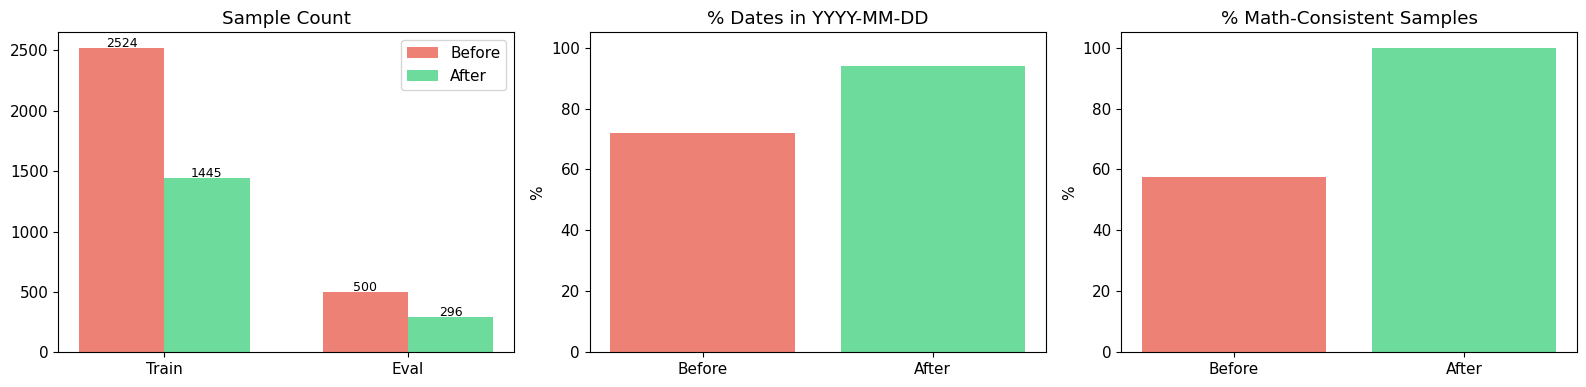

In [25]:
# Reload originals for comparison
orig_train = load_jsonl('../data/train.jsonl')
orig_eval = load_jsonl('../data/eval.jsonl')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sample count
labels = ['Train', 'Eval']
before = [len(orig_train), len(orig_eval)]
after = [len(train), len(eval_data)]
x = range(len(labels))
w = 0.35
axes[0].bar([i - w/2 for i in x], before, w, label='Before', color='#e74c3c', alpha=0.7)
axes[0].bar([i + w/2 for i in x], after, w, label='After', color='#2ecc71', alpha=0.7)
axes[0].set_title('Sample Count')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
for i in x:
    axes[0].text(i - w/2, before[i] + 5, str(before[i]), ha='center', fontsize=9)
    axes[0].text(i + w/2, after[i] + 5, str(after[i]), ha='center', fontsize=9)

# Date format comparison
orig_std = sum(1 for ex in orig_train + orig_eval if re.match(r'^\d{4}-\d{2}-\d{2}$', json.loads(ex['output']).get('invoice_date', '')))
new_std = sum(1 for ex in train + eval_data if re.match(r'^\d{4}-\d{2}-\d{2}$', json.loads(ex['output']).get('invoice_date', '')))
axes[1].bar(['Before', 'After'], 
            [orig_std/(len(orig_train)+len(orig_eval))*100, new_std/(len(train)+len(eval_data))*100],
            color=['#e74c3c', '#2ecc71'], alpha=0.7)
axes[1].set_title('% Dates in YYYY-MM-DD')
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('%')

# Math consistency
orig_math = sum(1 for ex in orig_train + orig_eval if is_math_consistent(ex))
new_math = sum(1 for ex in train + eval_data if is_math_consistent(ex))
axes[2].bar(['Before', 'After'],
            [orig_math/(len(orig_train)+len(orig_eval))*100, new_math/(len(train)+len(eval_data))*100],
            color=['#e74c3c', '#2ecc71'], alpha=0.7)
axes[2].set_title('% Math-Consistent Samples')
axes[2].set_ylim(0, 105)
axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()

---
## 12. Save Cleaned Data

In [26]:
import shutil
import os

# Backup originals
os.makedirs('../data/backup', exist_ok=True)
shutil.copy('../data/train.jsonl', '../data/backup/train_original.jsonl')
shutil.copy('../data/eval.jsonl', '../data/backup/eval_original.jsonl')
print('Originals backed up to data/backup/')

# Save cleaned versions
save_jsonl(train, '../data/train.jsonl')
save_jsonl(eval_data, '../data/eval.jsonl')

print(f'\nCleaned data saved:')
print(f'  data/train.jsonl — {len(train)} samples')
print(f'  data/eval.jsonl  — {len(eval_data)} samples')
print(f'\nChanges applied:')
print(f'  - Standardized all dates to YYYY-MM-DD')
print(f'  - Removed {len(orig_train) - len(train) + len(orig_eval) - len(eval_data)} math-inconsistent samples')
print(f'\nNext: Re-upload these files to Colab for training')

Originals backed up to data/backup/

Cleaned data saved:
  data/train.jsonl — 1445 samples
  data/eval.jsonl  — 296 samples

Changes applied:
  - Standardized all dates to YYYY-MM-DD
  - Removed 1283 math-inconsistent samples

Next: Re-upload these files to Colab for training
